In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
from epiweeks import Week
import matplotlib.pyplot as plt 
from scipy.special import inv_boxcox 
from matplotlib.gridspec import GridSpec

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'

plt.rcParams['axes.labelsize'] = 14 # Axis labels
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick labels
plt.rcParams['font.size'] = 14  # General font size
FONT = 10

In [2]:
df = pd.read_csv('data/dengue_BR.csv.gz')
df.date = pd.to_datetime(df.date)
max_date = df.date.max()
epi_week = Week.fromdate(df.date.max())
for_week = epi_week.week
for_week

11

In [3]:
df_crps = pd.read_csv(f'forecast_tables/for_ensemble_dengue.csv')
df_crps.date = pd.to_datetime(df_crps.date)
df_crps.head()

,lower_95,pred,upper_95,date,state
0,51.438963,63.570012,78.561973,2026-03-22,AL
1,57.712526,70.063959,85.058802,2026-03-29,AL
2,57.349377,69.730208,84.783866,2026-04-05,AL
3,341.356476,453.583043,602.705943,2026-03-22,BA
4,371.886281,485.790662,634.582610,2026-03-29,BA


In [4]:
df_ens = pd.read_csv('/Users/eduardoaraujo/Documents/Github/2nd_IMDC_sprint_results/predictions/ensemble_median_2026.csv.gz')
df_ens.date = pd.to_datetime(df_ens.date)
df_ens = df_ens.loc[(df_ens.date <= '2026-04-09') & (df_ens.date >= '2025-12-28')]
df_ens.head()

,date,state,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,model_id,mu,sigma
12,2025-12-28,DF,23.045363,27.963484,33.985483,65.776193,156.000000,407.000000,666.185386,1214.468249,1922.372942,E_median_top,5.261209,1.173545
13,2026-01-04,DF,42.000000,58.795031,77.867998,123.004333,196.610069,476.000000,1052.331130,1111.737226,1657.861057,E_median_top,5.575477,0.937674
14,2026-01-11,DF,62.827292,74.998295,88.642122,125.724635,213.000000,556.000000,1311.000000,2288.000000,3378.000000,E_median_top,6.054835,1.056246
15,2026-01-18,DF,72.267920,84.217248,103.424548,159.418570,260.950960,648.000000,1328.213204,2093.194633,3316.843225,E_median_top,6.109533,1.019017
16,2026-01-25,DF,70.856227,87.977831,118.427774,175.234099,303.169305,816.712648,1776.000000,3102.000000,4845.000000,E_median_top,6.306190,1.112017


In [5]:
def make_plot_new(ax, state, for_week, df_crps, df_ens):

    df_ens_ = df_ens.loc[df_ens.state== state]
    
    data = pd.read_csv(f'data/dengue_{state}.csv.gz')
        
    data.date = pd.to_datetime(data.date)

    data = data.sort_values(by = 'date')
    
    data = data.tail(12)
    
    data['casos'] = inv_boxcox(data['casos'].values, 0.05) -1
    
    df_ens_crps = df_crps.loc[df_crps.state == state]
    
    ax.plot(data.date,  data.casos, color = 'black', linewidth = 2, linestyle = '-', label = 'Casos')

    ax.plot(df_ens_.date, df_ens_.pred, color = 'blue', linestyle = 'dashed',label = 'Ensemble')
    ax.fill_between(df_ens_.date, df_ens_.lower_90, df_ens_.upper_90, color = 'blue',alpha = 0.05)

    ax.plot([data.date.values[-1], df_ens_crps.date.values[0]], [data['casos'].values[-1], df_ens_crps.pred.values[0]], ls = '--', color = 'black')
        
    ax.plot(df_ens_crps.date,  df_ens_crps.pred, color = 'tab:red', label = 'Forecast curto prazo', zorder = 5)
                
    ax.fill_between(df_ens_crps.date, df_ens_crps.lower_95, df_ens_crps.upper_95, color = 'tab:red', alpha = 0.2, zorder = 5)
           
    ax.set_xlabel('Data')
    ax.set_ylabel('Novos Casos')
    ax.set_title(f'Forecast casos prováveis - {state}')
    ax.legend()
    ax.grid(color = 'gray', alpha = 0.25)

        

In [6]:
def make_plot_en(ax, state, for_week, df_crps, df_ens):

    df_ens_ = df_ens.loc[df_ens.state== state]
    
    data = pd.read_csv(f'data/dengue_{state}.csv.gz')
        
    data.date = pd.to_datetime(data.date)

    data = data.sort_values(by = 'date')
    
    data = data.tail(12)
    
    data['casos'] = inv_boxcox(data['casos'].values, 0.05) -1
    
    df_ens_crps = df_crps.loc[df_crps.state == state]
    
    ax.plot(data.date,  data.casos, color = 'black', linewidth = 2, linestyle = '-', label = 'Observed cases')

    ax.plot(df_ens_.date, df_ens_.pred, color = 'blue', linestyle = 'dashed',label = 'Ensemble')
    ax.fill_between(df_ens_.date, df_ens_.lower_90, df_ens_.upper_90, color = 'blue',alpha = 0.05)

    ax.plot([data.date.values[-1], df_ens_crps.date.values[0]], [data['casos'].values[-1], df_ens_crps.pred.values[0]], ls = '--', color = 'black')
        
    ax.plot(df_ens_crps.date,  df_ens_crps.pred, color = 'tab:red', label = 'Short-term forecast', zorder = 5)
                
    ax.fill_between(df_ens_crps.date, df_ens_crps.lower_95, df_ens_crps.upper_95, color = 'tab:red', alpha = 0.2, zorder = 5)
           
    ax.set_xlabel('Date')
    ax.set_ylabel('Probable cases')
    ax.set_title(f'Forecast probable cases - {state}')
    ax.legend()
    ax.grid(color = 'gray', alpha = 0.25)

        

_, ax = plt.subplots(figsize = (12,5.5))

make_plot_en(ax, 'GO', for_week, df_crps, df_ens)
plt.savefig('fig_for_GO.png', dpi = 400, bbox_inches = 'tight')
plt.show()

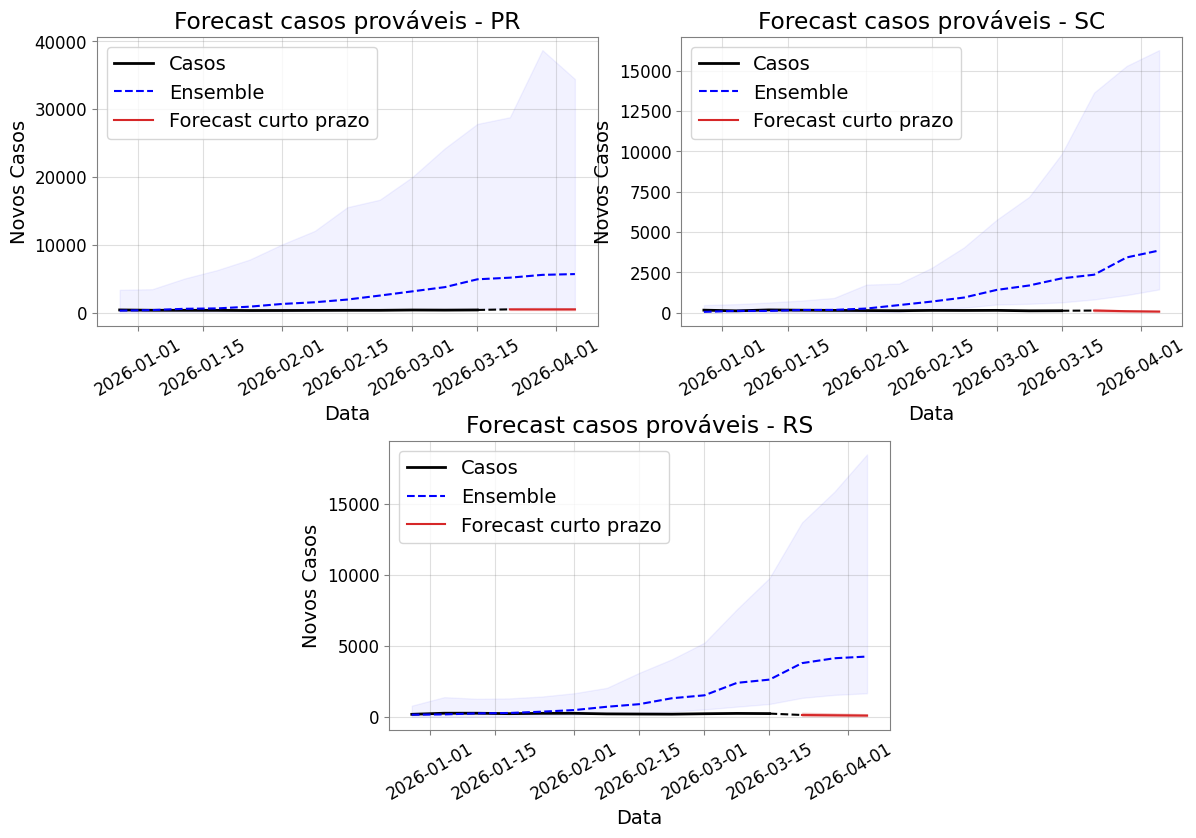

In [7]:
fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 7, figure=fig)

ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 4:7])
ax3 = fig.add_subplot(gs[1, 2:5])  # span both columns

make_plot_new(ax1, 'PR', for_week, df_crps, df_ens)
make_plot_new(ax2, 'SC', for_week, df_crps, df_ens)
make_plot_new(ax3, 'RS', for_week, df_crps, df_ens)

plt.subplots_adjust(wspace = -0.3, hspace = 0.4)

for ax_ in [ax1, ax2, ax3]:
    for label in ax_.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('center')
    #fig.autofmt_xdate(rotation=30, ha='center')

plt.savefig('figures/figures_sul.png', dpi = 300, bbox_inches = 'tight')

plt.show()

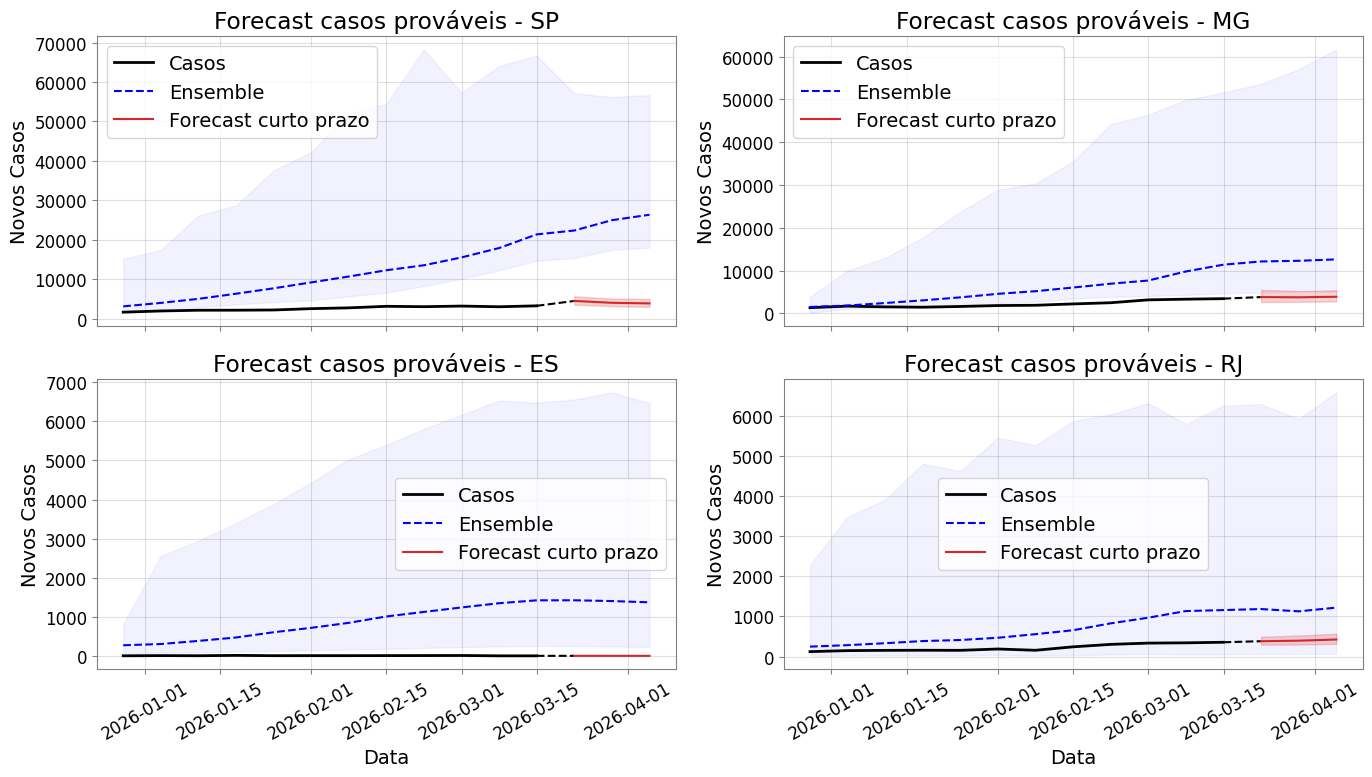

In [8]:
_,ax = plt.subplots(2,2, figsize = (14,8))

make_plot_new(ax[0,0], 'SP', for_week, df_crps, df_ens)
make_plot_new(ax[0,1], 'MG', for_week, df_crps, df_ens)
make_plot_new(ax[1,0], 'ES', for_week, df_crps, df_ens)
make_plot_new(ax[1,1], 'RJ', for_week, df_crps, df_ens)

#plt.subplots_adjust(wspace = -0.3, hspace = 0.4)

_.autofmt_xdate(rotation=30, ha='center')

plt.tight_layout()
plt.savefig('figures/figures_sud.png', dpi = 300, bbox_inches = 'tight')

plt.show()

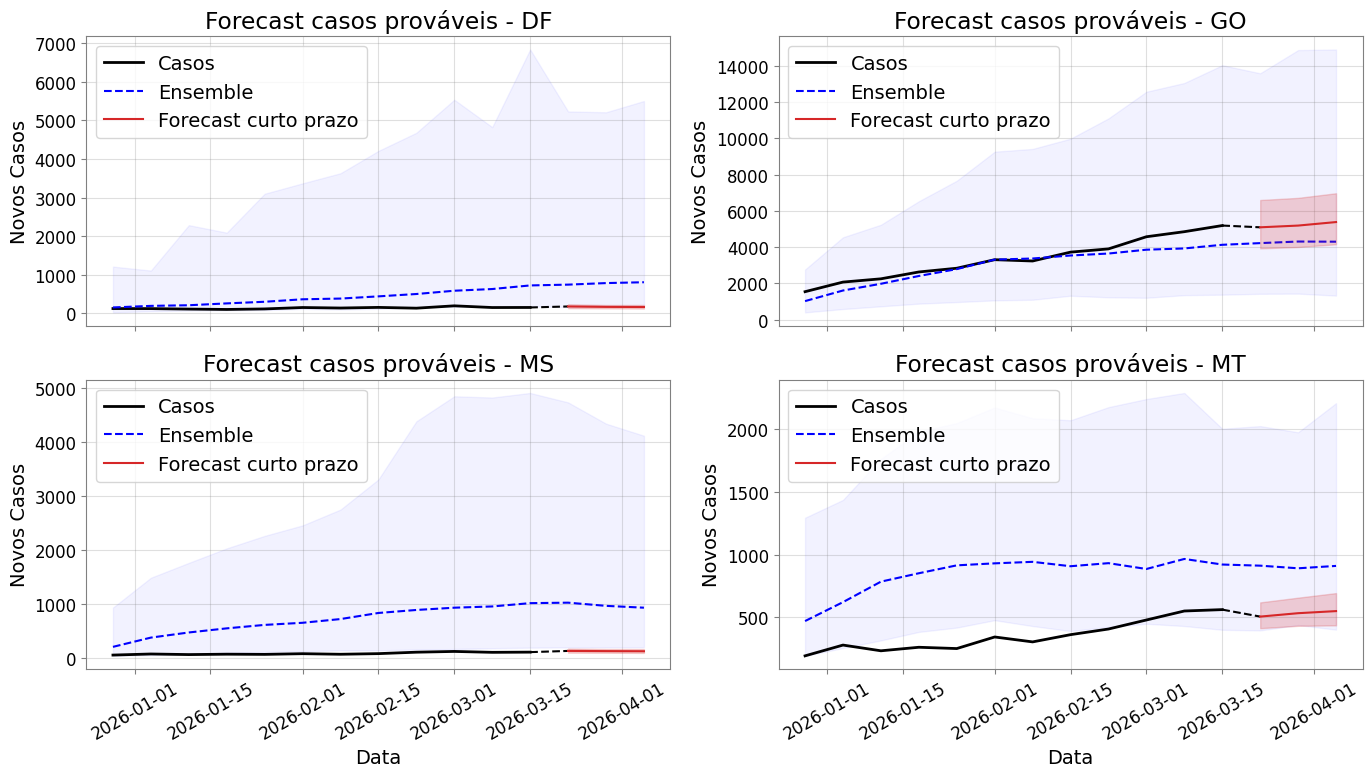

In [9]:
_,ax = plt.subplots(2,2, figsize = (14,8))

make_plot_new(ax[0,0], 'DF', for_week, df_crps, df_ens)
make_plot_new(ax[0,1], 'GO', for_week, df_crps, df_ens)
make_plot_new(ax[1,0], 'MS', for_week, df_crps, df_ens)
make_plot_new(ax[1,1], 'MT', for_week, df_crps, df_ens)

#plt.subplots_adjust(wspace = -0.3, hspace = 0.4)

_.autofmt_xdate(rotation=30, ha='center')

plt.tight_layout()
plt.savefig('figures/figures_mid.png', dpi = 300, bbox_inches = 'tight')

plt.show()

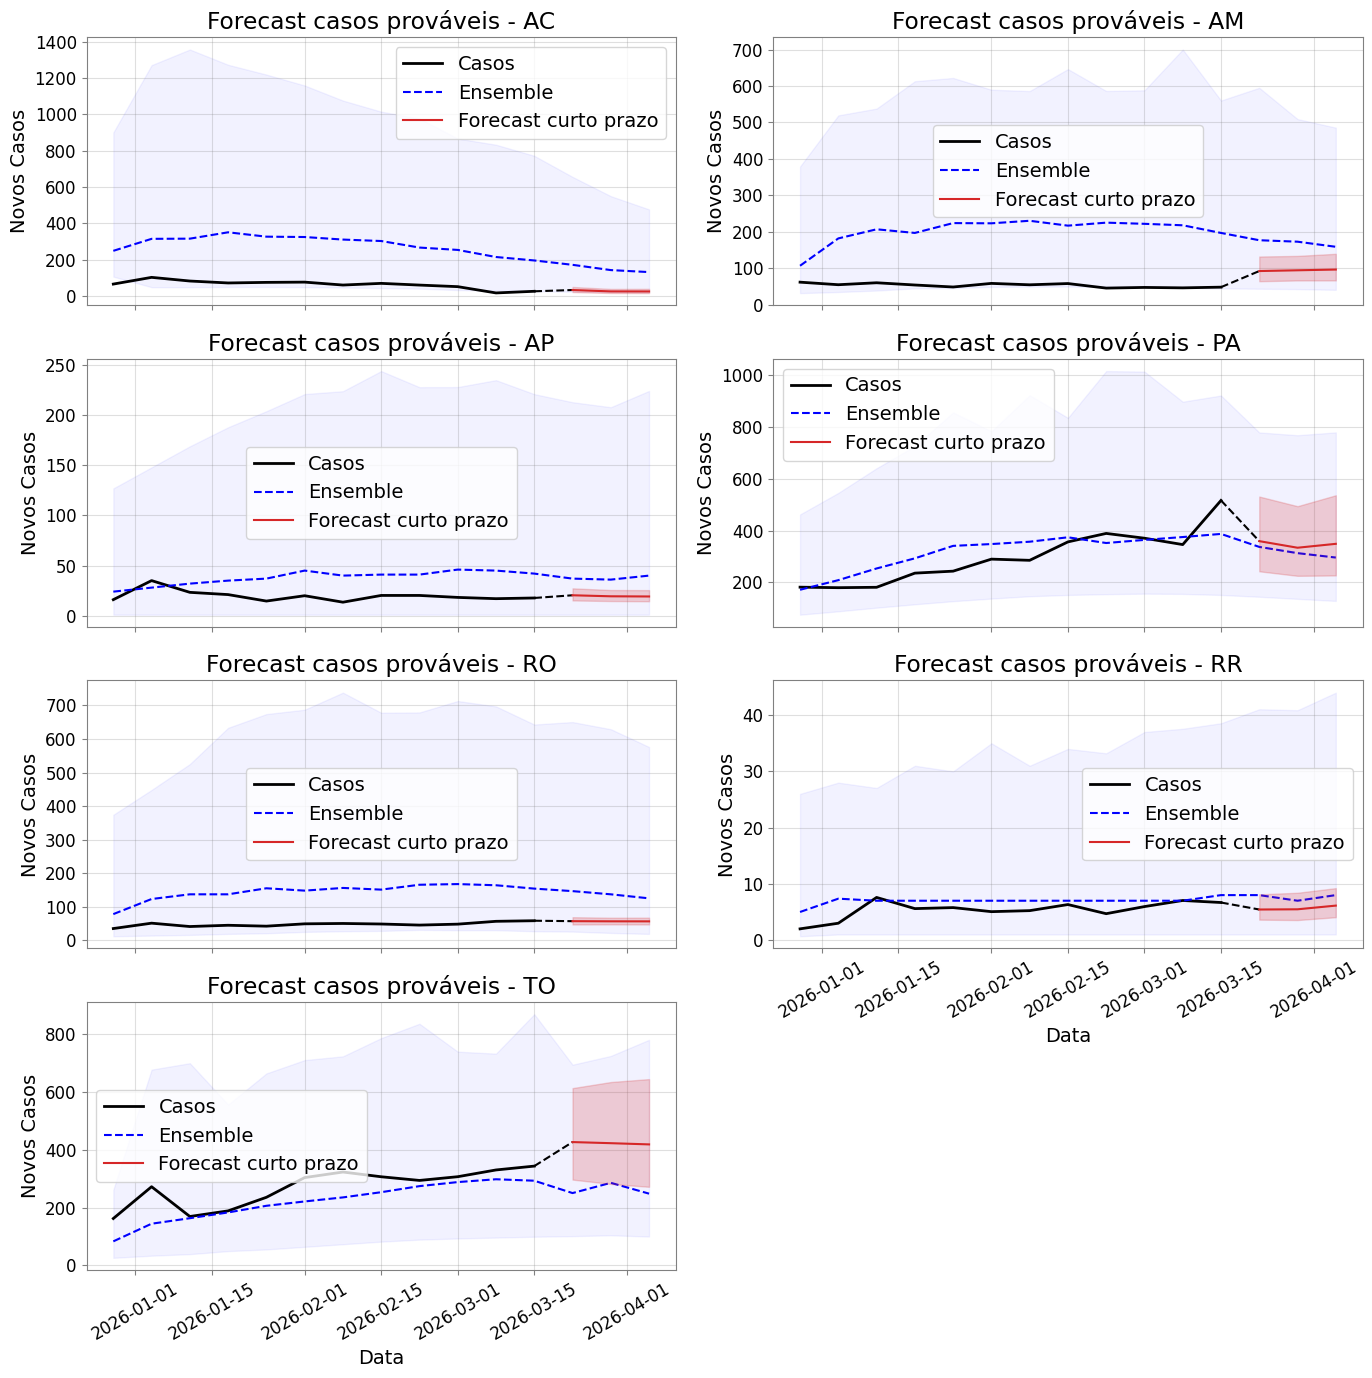

In [10]:
_,ax = plt.subplots(4,2, figsize = (14,14), sharex = False)

make_plot_new(ax[0,0], 'AC', for_week, df_crps, df_ens)
make_plot_new(ax[0,1], 'AM', for_week, df_crps, df_ens)
make_plot_new(ax[1,0], 'AP', for_week, df_crps, df_ens)
make_plot_new(ax[1,1], 'PA', for_week, df_crps, df_ens)
make_plot_new(ax[2,0], 'RO', for_week, df_crps, df_ens)
make_plot_new(ax[2,1], 'RR', for_week, df_crps, df_ens)
make_plot_new(ax[3,0], 'TO', for_week, df_crps, df_ens)
#plt.subplots_adjust(wspace = -0.3, hspace = 0.4)

ax[3,1].axis('off')
#_.autofmt_xdate(rotation=30, ha='center')

for ax_ in [ax[3,0], ax[2,1]]: 
    for label in ax_.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('center')
        
for ax_ in [ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0]]:

    ax_.set_xlabel('')
    ax_.set_xticklabels([])

plt.tight_layout()
plt.subplots_adjust(hspace = 0.2)
plt.savefig('figures/figures_no.png', dpi = 300, bbox_inches = 'tight')

plt.show()

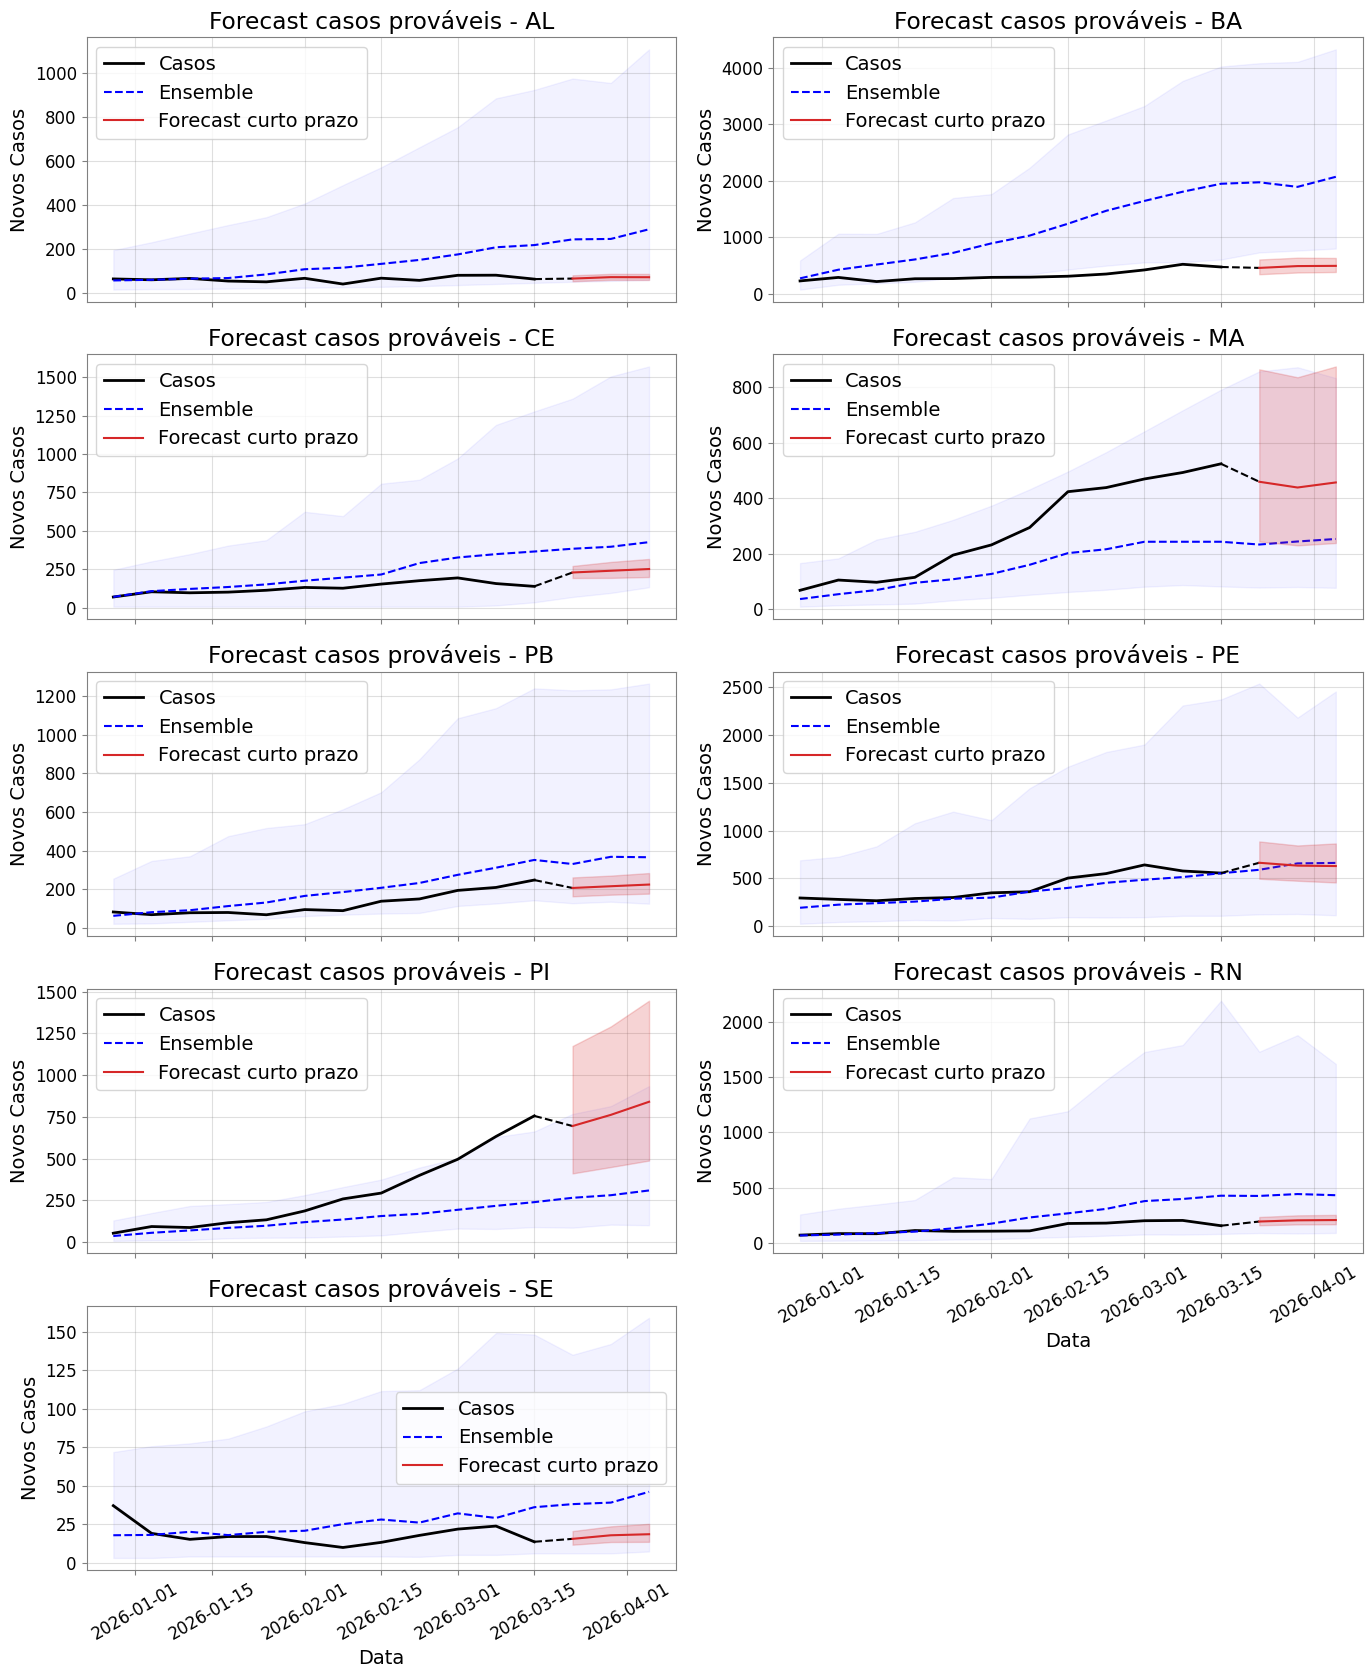

In [11]:
_,ax = plt.subplots(5,2, figsize = (14,17), sharex = False)

make_plot_new(ax[0,0], 'AL', for_week, df_crps, df_ens)
make_plot_new(ax[0,1], 'BA', for_week, df_crps, df_ens)
make_plot_new(ax[1,0], 'CE', for_week, df_crps, df_ens)
make_plot_new(ax[1,1], 'MA', for_week, df_crps, df_ens)
make_plot_new(ax[2,0], 'PB', for_week, df_crps, df_ens)
make_plot_new(ax[2,1], 'PE', for_week, df_crps, df_ens)
make_plot_new(ax[3,0], 'PI', for_week, df_crps, df_ens)
make_plot_new(ax[3,1], 'RN', for_week, df_crps, df_ens)
make_plot_new(ax[4,0], 'SE', for_week, df_crps, df_ens)#plt.subplots_adjust(wspace = -0.3, hspace = 0.4)

ax[4,1].axis('off')
#_.autofmt_xdate(rotation=30, ha='center')

for ax_ in [ax[4,0], ax[3,1]]: 
    for label in ax_.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('center')
        
for ax_ in [ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0],
           ax[2,1], ax[3,0]]:

    ax_.set_xlabel('')
    ax_.set_xticklabels([])

plt.tight_layout()
plt.subplots_adjust(hspace = 0.2)
plt.savefig('figures/figures_ne.png', dpi = 300, bbox_inches = 'tight')

plt.show()

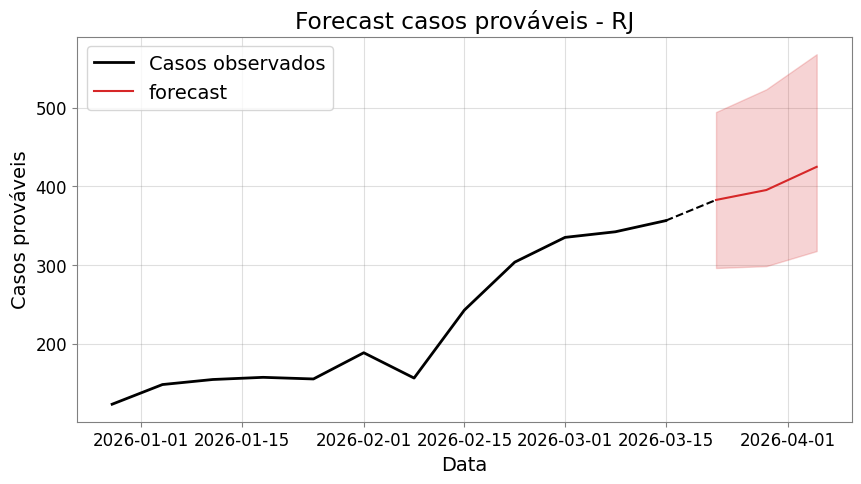

In [12]:
state = 'RJ'

_, ax= plt.subplots(figsize =(10, 5))

data = pd.read_csv(f'data/dengue_{state}.csv.gz')
        
data.date = pd.to_datetime(data.date)

data = data.sort_values(by = 'date')
    
data = data.tail(12)
    
data['casos'] = inv_boxcox(data['casos'].values, 0.05) -1
    
df_ens_crps = df_crps.loc[df_crps.state == state]
    
ax.plot(data.date,  data.casos, color = 'black', linewidth = 2, linestyle = '-', label = 'Casos observados')


ax.plot([data.date.values[-1], df_ens_crps.date.values[0]], [data['casos'].values[-1], df_ens_crps.pred.values[0]], ls = '--', color = 'black')
        
ax.plot(df_ens_crps.date,  df_ens_crps.pred, color = 'tab:red', label = 'forecast', zorder = 5)
                
ax.fill_between(df_ens_crps.date, df_ens_crps.lower_95, df_ens_crps.upper_95, color = 'tab:red', alpha = 0.2, zorder = 5)
           
ax.set_xlabel('Data')
ax.set_ylabel('Casos prováveis')
ax.set_title(f'Forecast casos prováveis - {state}')
ax.legend()
ax.grid(color = 'gray', alpha = 0.25)

plt.show()